[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/StockChangeDistribution.ipynb)

_Run this notebook in the browser — no install needed._

# Stock Change Distribution

Explore the distribution of daily changes in a stock price.

## What's in the data

`prices` is the **daily closing level of the S&P 500 index** (in points).

We study the **daily percent change**

$$\text{change}_t = 100 \times \left(\frac{\text{price}_t}{\text{price}_{t-1}} - 1\right)$$

i.e. how far the index moved from one trading day's close to the next, as a
percentage. Up days are positive, down days negative. (The price *ratio* is
always positive, so this is always well defined.)

**Question:** is that day-to-day movement well described by a normal
(bell-curve) distribution? Below we plot the histogram against a best-fit
normal three ways — full view, a 0-10 day zoom, and a log scale — first with
the x-axis in percent, then with the x-axis as a z-score.

In [1]:
# Colab doesn't ship yfinance. %pip installs into whichever kernel is running,
# so this works on Colab and is a harmless no-op locally.
%pip install -q yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

# --- Data ---------------------------------------------------------------
ticker = "^GSPC"                     # S&P 500  (use "^DJI" for the Dow Jones)
data = yf.download(ticker, start="2000-01-01", auto_adjust=True,
                   progress=False, multi_level_index=False)

prices = data["Close"].dropna()     # daily closing index level, in points

# Daily percent change from the previous close. prices/prices.shift(1) is
# always positive, so this is always defined; it is simply negative on down days.
change = (prices.pct_change() * 100).dropna()
change.name = "Daily % change"

# --- Summary statistics -----------------------------------------------------
mu = change.mean()                  # average daily change, in percent
sigma = change.std()                # standard deviation ("1 sigma"), in percent
n = len(change)

# --- Histogram bins (shared by every plot below) --------------------------
BIN_WIDTH_PCT = 0.5                  # width of each histogram bar, in percent
lo = np.floor(change.min() / BIN_WIDTH_PCT) * BIN_WIDTH_PCT
hi = np.ceil(change.max() / BIN_WIDTH_PCT) * BIN_WIDTH_PCT
bins = np.arange(lo, hi + BIN_WIDTH_PCT, BIN_WIDTH_PCT)

print(f"{n:,} trading days   mean = {mu:+.3f}%   std dev = {sigma:.3f}%")

/Users/dhb/Documents/Python/PythonTeachingCode/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


6,708 trading days   mean = +0.032%   std dev = 1.212%


In [3]:
def hist_panel(values, bins, xlabel, title, scale="full", mark_sigma=False):
    """Draw one histogram of `values` with the best-fit normal curve on top.

    scale : "full"  linear y-axis, autoscaled  -> the bell curve fits the bulk
            "zoom"  linear y-axis capped at 10  -> rare tail days become visible
            "log"   logarithmic y-axis          -> every frequency on one axis
    mark_sigma : draw dashed lines at -3 and +3 (used for the z-score plots)
    """
    bw = bins[1] - bins[0]
    grid = np.linspace(bins[0], bins[-1], 1000)
    m, s = stats.norm.fit(values)
    expected_days = stats.norm.pdf(grid, m, s) * len(values) * bw

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(values, bins=bins, color="steelblue", alpha=0.6, label="Actual trading days")
    ax.plot(grid, expected_days, "r-", lw=2, label="If daily moves were normal")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of days")
    ax.set_title(title)

    if scale == "zoom":
        ax.set_ylim(0, 10)
    elif scale == "log":
        ax.set_yscale("log")
        ax.set_ylim(bottom=0.5)

    if mark_sigma:
        for edge in (-3, 3):
            ax.axvline(edge, color="0.4", ls="--", lw=1)
            ax.annotate(f"{edge:+d}σ", xy=(edge, 0), xycoords=("data", "axes fraction"),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", color="0.4", fontsize=9)

    ax.legend()
    plt.tight_layout()
    plt.show()

## Three views, x-axis in percent

Same histogram (bar width = 0.5 percentage points) and same best-fit normal
curve, shown three times with different vertical axes.

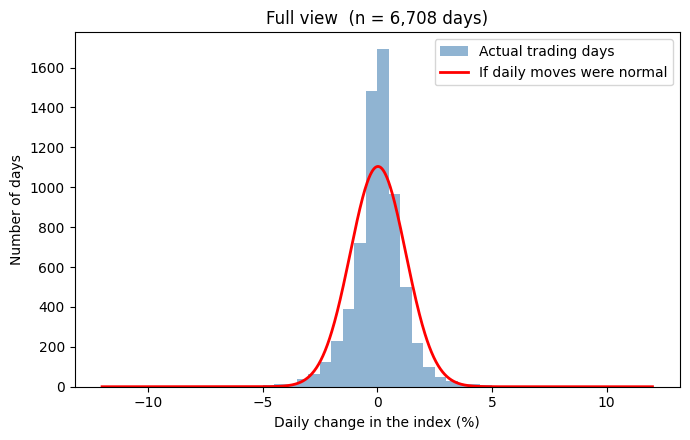

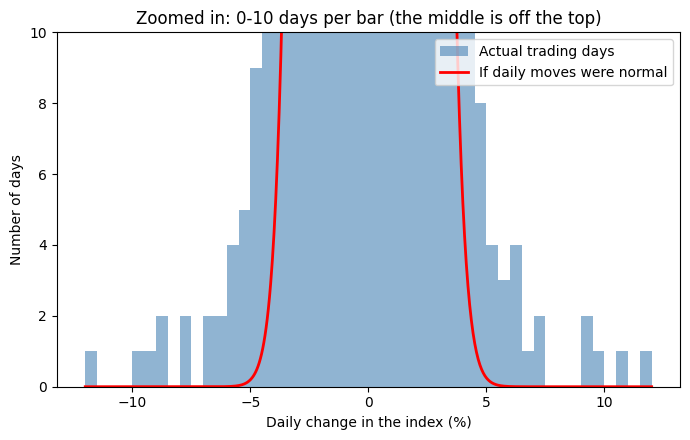

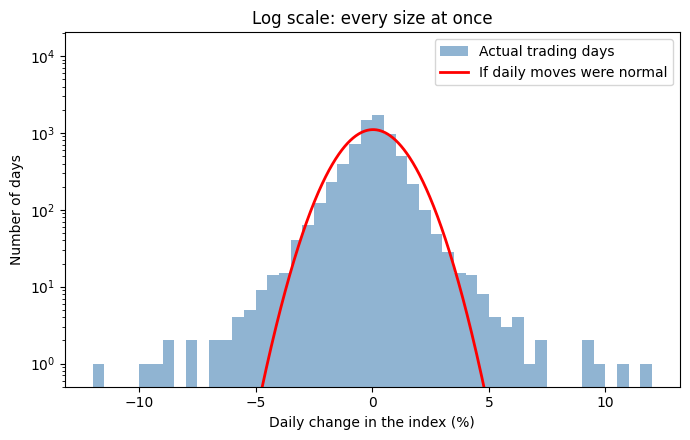

In [4]:
xlabel_pct = "Daily change in the index (%)"

hist_panel(change, bins, xlabel_pct,
           f"Full view  (n = {n:,} days)", scale="full")

hist_panel(change, bins, xlabel_pct,
           "Zoomed in: 0-10 days per bar (the middle is off the top)", scale="zoom")

hist_panel(change, bins, xlabel_pct,
           "Log scale: every size at once", scale="log")

## The same three views, x-axis as a z-score

Now rescale the x-axis so 1 unit = 1 standard deviation:

$$z = \frac{\text{change} - \text{mean}}{\text{standard deviation}}$$

The histogram is identical — only the axis labels change. A true normal
distribution would have essentially nothing past |z| = 3 (dashed lines); the
market spends a lot of days out there.

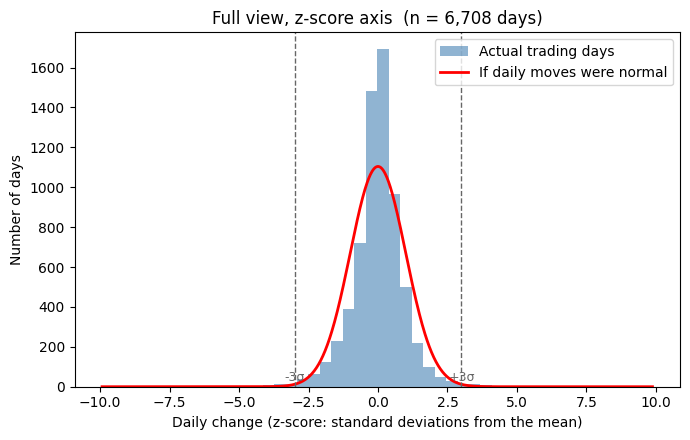

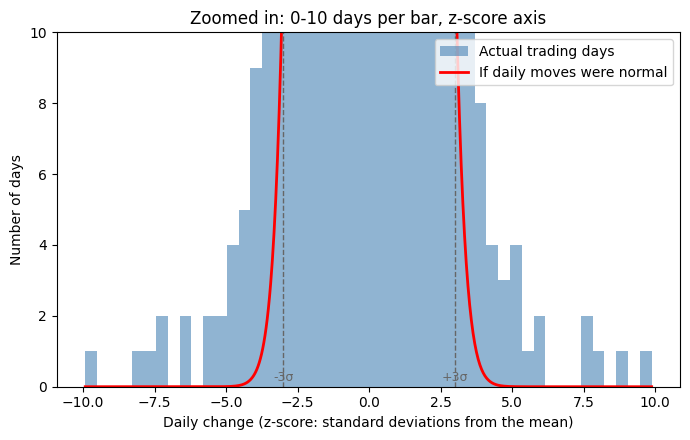

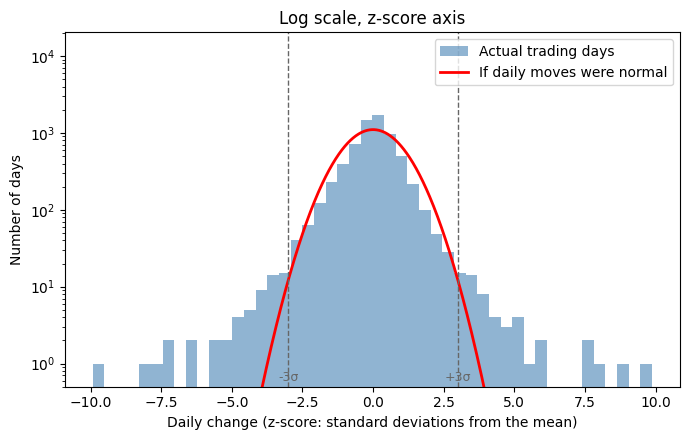

In [5]:
z = (change - mu) / sigma           # daily change measured in standard deviations
bins_z = (bins - mu) / sigma        # exact same bar edges, rescaled

xlabel_z = "Daily change (z-score: standard deviations from the mean)"

hist_panel(z, bins_z, xlabel_z,
           f"Full view, z-score axis  (n = {n:,} days)", scale="full", mark_sigma=True)

hist_panel(z, bins_z, xlabel_z,
           "Zoomed in: 0-10 days per bar, z-score axis", scale="zoom", mark_sigma=True)

hist_panel(z, bins_z, xlabel_z,
           "Log scale, z-score axis", scale="log", mark_sigma=True)

In [6]:
# --- The numbers behind the pictures --------------------------------------
start, end = change.index.min().date(), change.index.max().date()

print(f"Source:  Yahoo Finance via the yfinance package,  ticker {ticker} (S&P 500)")
print(f"Days included:  {n:,} trading days,  {start} to {end}")
print(f"Mean daily change:   {mu:+.4f}%")
print(f"Std deviation (1σ):  {sigma:.4f}%")
print()
print(f"{'move':>18} | {'normal predicts':>16} | {'actual days':>12}")
print("-" * 54)
for k in (1, 2, 3, 4, 5):
    cutoff = k * sigma
    predicted = n * 2 * (1 - stats.norm.cdf(k))
    actual = int(np.sum(np.abs(change - mu) > cutoff))
    print(f"  beyond {k}σ  (±{cutoff:4.1f}%) | {predicted:>16.2f} | {actual:>12}")
print()
print(f"Biggest one-day drop: {change.min():6.1f}%   ({z.min():+.1f}σ)   on {change.idxmin().date()}")
print(f"Biggest one-day gain: {change.max():6.1f}%   ({z.max():+.1f}σ)   on {change.idxmax().date()}")
print(f"Excess kurtosis (0 = normal, higher = fatter tails): {stats.kurtosis(change):.1f}")

Source:  Yahoo Finance via the yfinance package,  ticker ^GSPC (S&P 500)
Days included:  6,708 trading days,  2000-01-04 to 2026-09-04
Mean daily change:   +0.0322%
Std deviation (1σ):  1.2118%

              move |  normal predicts |  actual days
------------------------------------------------------
  beyond 1σ  (± 1.2%) |          2128.52 |         1384
  beyond 2σ  (± 2.4%) |           305.22 |          329
  beyond 3σ  (± 3.6%) |            18.11 |          105
  beyond 4σ  (± 4.8%) |             0.42 |           45
  beyond 5σ  (± 6.1%) |             0.00 |           23

Biggest one-day drop:  -12.0%   (-9.9σ)   on 2020-03-16
Biggest one-day gain:   11.6%   (+9.5σ)   on 2008-10-13
Excess kurtosis (0 = normal, higher = fatter tails): 10.5
